# Processamento de Linguagem Natural — 1ª Lista de Exercícios

**Universidade Federal de Alagoas — Instituto de Computação**
Professor: Thales Vieira

**Base de textos utilizada (questões 4 a 6):** enunciados de questões do ENEM (provas regulares),
coletados pelo *scrapper* do projeto e tratados em `preprocessing/preprocess_questions.py`.
O arquivo consumido aqui é `data/questions_data_set_preprocessed.csv`, na coluna `questao_limpa`.
As provas de **2021 e 2022** foram excluídas da análise; restam os anos de 2020, 2023, 2024 e 2025.

---
## Questão 1

Escreva uma função que recebe uma senha como entrada e verifica se ela atende aos seguintes critérios de uma senha forte:

- Pelo menos 8 caracteres
- Pelo menos uma letra maiúscula e uma letra minúscula
- Pelo menos um dígito
- Pelo menos um caractere especial (por exemplo, `!@#$%&*`)

A função deve retornar `True` se a senha for forte e `False` caso contrário.

### Resposta

Cada critério do enunciado vira uma busca independente com `re.search`. Como `re.search` procura a ocorrência em
qualquer posição da string, basta uma classe de caracteres por critério. O comprimento mínimo é verificado com
`re.fullmatch(r".{8,}", ...)`, que só casa se a string inteira tiver 8 ou mais caracteres.

In [1]:
import re

def isValidPassword(password: str) -> bool:
    has_digit = bool(re.search(r"\d", password))                    # Verifica se tem ao menos um número
    has_upper = bool(re.search(r"[A-Z]", password))                 # Verifica se tem ao menos uma letra maiúscula
    has_lower = bool(re.search(r"[a-z]", password))                 # Verifica se tem ao menos uma letra minúscula
    has_special_char = bool(re.search(r"[!@#$%&*]", password))      # Verifica se tem ao menos um caracter especial
    has_eight_more_char = bool(re.fullmatch(r".{8,}", password, re.DOTALL))  # Verifica se tem ao menos 8 caracteres

    return has_digit and has_upper and has_lower and has_special_char and has_eight_more_char

### Bateria de testes

In [2]:
testes_senha = [
    # (senha, resultado esperado, motivo)
    ("SenhaCerta123@",  True,  "atende a todos os critérios"),
    ("senhaSemNumero@", False, "não tem dígito"),
    ("Curta8!",         False, "tem menos de 8 caracteres"),
    ("12345678*",       False, "não tem letras"),
    ("SEMLOWER123*",    False, "não tem minúscula"),
    ("semupper123&",    False, "não tem maiúscula"),
    ("SemEspecial123",  False, "não tem caractere especial"),
    ("Abc!2345",        True,  "caso mínimo: exatamente 8 caracteres"),
    ("A1b@" * 2,        True,  "repetição que satisfaz todos os critérios"),
]

print(f"{'SENHA':<20} {'OBTIDO':<8} {'ESPERADO':<10} {'OK':<4} MOTIVO")
print("-" * 92)
for senha, esperado, motivo in testes_senha:
    obtido = isValidPassword(senha)
    print(f"{senha:<20} {str(obtido):<8} {str(esperado):<10} {'OK' if obtido == esperado else 'FALHA':<4} {motivo}")

SENHA                OBTIDO   ESPERADO   OK   MOTIVO
--------------------------------------------------------------------------------------------
SenhaCerta123@       True     True       OK   atende a todos os critérios
senhaSemNumero@      False    False      OK   não tem dígito
Curta8!              False    False      OK   tem menos de 8 caracteres
12345678*            False    False      OK   não tem letras
SEMLOWER123*         False    False      OK   não tem minúscula
semupper123&         False    False      OK   não tem maiúscula
SemEspecial123       False    False      OK   não tem caractere especial
Abc!2345             True     True       OK   caso mínimo: exatamente 8 caracteres
A1b@A1b@             True     True       OK   repetição que satisfaz todos os critérios


### Explicação

Foram usadas 5 variáveis booleanas, uma para cada condição do enunciado, e o retorno é a conjunção (`and`) de todas.
Escrever um critério por variável mantém a função legível e facilita trocar ou relaxar uma regra isoladamente —
uma expressão regular única com *lookaheads* (`^(?=.*\d)(?=.*[A-Z])...`) daria o mesmo resultado, mas seria bem
menos legível. O `re.DOTALL` no `fullmatch` garante que uma senha contendo `\n` também seja medida corretamente,
já que `.` por padrão não casa quebra de linha.

---
## Questão 2

Escreva uma função que recebe um endereço de e-mail como entrada e verifica se ele é válido de acordo com as regras
básicas de formação de um e-mail. Utilize expressões regulares para realizar a validação. A função deve retornar
`True` se o endereço de e-mail for válido e `False` caso contrário.

### Resposta

Para as regras práticas foi adotado um subconjunto prático da RFC 5322:

| Parte | Regra |
|---|---|
| Parte local (antes do `@`) | um ou mais blocos de caracteres permitidos, separados por pontos **simples** — logo, não pode começar nem terminar com ponto, nem conter `..` |
| `@` | exatamente um |
| Domínio | um ou mais rótulos separados por ponto; cada rótulo começa e termina com letra ou dígito e pode conter hífens no meio |
| TLD | último rótulo com **pelo menos 2 letras** |
| Geral | sem espaços em branco e sem caracteres fora das classes acima |

A regex é montada em partes nomeadas e concatenada, para que cada regra fique explícita no código.

In [3]:
import re

# Cada trecho da regex corresponde a uma regra da tabela acima.
_ATOM        = r"[A-Za-z0-9!#$%&'*+/=?^_`{|}~-]+"           # bloco válido da parte local
_LOCAL       = rf"{_ATOM}(?:\.{_ATOM})*"                    # blocos separados por ponto simples
_LABEL       = r"[A-Za-z0-9](?:[A-Za-z0-9-]*[A-Za-z0-9])?"  # rótulo de domínio (hífen só no meio)
_TLD         = r"[A-Za-z]{2,}"                              # domínio de topo: 2 ou mais letras
EMAIL_REGEX  = re.compile(rf"^{_LOCAL}@(?:{_LABEL}\.)+{_TLD}$")

def isValidEmail(email: str) -> bool:
    """Retorna True se `email` obedece às regras básicas de formação de um endereço de e-mail."""
    if not isinstance(email, str):
        return False
    return bool(EMAIL_REGEX.fullmatch(email.strip()))

### Bateria de testes

In [4]:
testes_email = [
    # válidos
    ("jose.riquelme@ic.ufal.br",      True,  "subdomínio e ponto na parte local"),
    ("aluno_2026@gmail.com",          True,  "underscore e dígitos"),
    ("a@b.co",                        True,  "caso mínimo aceito (TLD com 2 letras)"),
    ("nome+tag@empresa-teste.com.br", True,  "'+' na parte local e hífen no domínio"),
    # inválidos
    ("sem-arroba.com",                False, "não tem '@'"),
    ("@dominio.com",                  False, "parte local vazia"),
    ("usuario@",                      False, "domínio vazio"),
    ("usuario@dominio",               False, "domínio sem TLD"),
    ("usuario@dominio.c",             False, "TLD com apenas 1 letra"),
    ("usu ario@dominio.com",          False, "espaço no endereço"),
    ("usuario@@dominio.com",          False, "dois '@'"),
    (".usuario@dominio.com",          False, "parte local começando com ponto"),
    ("usuario.@dominio.com",          False, "parte local terminando com ponto"),
    ("usu..ario@dominio.com",         False, "pontos consecutivos na parte local"),
    ("usuario@-dominio.com",          False, "rótulo de domínio começando com hífen"),
    ("usuario@dominio..com",          False, "rótulo de domínio vazio"),
]

print(f"{'E-MAIL':<32} {'OBTIDO':<8} {'ESPERADO':<10} {'OK':<7} MOTIVO")
print("-" * 104)
acertos = 0
for email, esperado, motivo in testes_email:
    obtido = isValidEmail(email)
    acertos += obtido == esperado
    print(f"{email:<32} {str(obtido):<8} {str(esperado):<10} {'OK' if obtido == esperado else 'FALHA':<7} {motivo}")
print("-" * 104)
print(f"{acertos}/{len(testes_email)} casos de teste com o resultado esperado.")

E-MAIL                           OBTIDO   ESPERADO   OK      MOTIVO
--------------------------------------------------------------------------------------------------------
jose.riquelme@ic.ufal.br         True     True       OK      subdomínio e ponto na parte local
aluno_2026@gmail.com             True     True       OK      underscore e dígitos
a@b.co                           True     True       OK      caso mínimo aceito (TLD com 2 letras)
nome+tag@empresa-teste.com.br    True     True       OK      '+' na parte local e hífen no domínio
sem-arroba.com                   False    False      OK      não tem '@'
@dominio.com                     False    False      OK      parte local vazia
usuario@                         False    False      OK      domínio vazio
usuario@dominio                  False    False      OK      domínio sem TLD
usuario@dominio.c                False    False      OK      TLD com apenas 1 letra
usu ario@dominio.com             False    False      OK      esp

### Explicação

O ponto central é usar `fullmatch` (ou os âncoras `^...$`): com `re.search` um endereço como `"xx usuario@dominio.com yy"`
seria aceito, porque a regex casaria apenas com o trecho do meio. Aqui usamos os dois — âncoras e `fullmatch` —
de forma redundante e intencional.

As duas regras que mais costumam escapar de regexes ingênuas do tipo `.+@.+\..+` são os **pontos consecutivos**
e os **rótulos de domínio vazios**. Ambas são resolvidas pela estrutura "bloco (`ponto` bloco)\*": como cada bloco
exige pelo menos um caractere (`+`), nem `a..b` nem `dominio..com` têm como casar.

---
## Questão 3

Considere o seguinte exemplo de referência de livro em formato de citação APA:

> Manning, C. D., Manning, C. D., & Schutze, H. (1999). Foundations of statistical natural language processing. MIT press.

Implemente uma função usando expressões regulares que extraia **cada autor**, **ano de publicação**, **título** e
**editora** do livro, para qualquer referência de livro neste formato.

### Resposta

A extração é feita em dois níveis:

1. **Regex estrutural** (`REFERENCIA_REGEX`) quebra a referência nos quatro campos:
   `<autores> (<ano>). <título>. <editora>.`
   O ano é reconhecido por `\(\s*(\d{4}[a-z]?)\s*\)` — o sufixo opcional em letra minúscula cobre o caso APA
   de desambiguação (`1999a`, `1999b`). O título usa quantificador **guloso** (`.+`) e a editora exige um trecho
   **sem pontos** (`[^.]+`): assim, a última sentença da referência vira a editora, e títulos com `:` ou subtítulos
   longos permanecem íntegros.

2. **Regex de autores** (`AUTOR_REGEX`) é aplicada com `finditer` sobre o bloco de autores, capturando cada par
   `Sobrenome, I. I.`. Usar `finditer` em vez de dar `split` em `,` e `&` é o que torna a função robusta a qualquer
   número de autores — a vírgula aparece tanto **entre** autores quanto **dentro** de um autor.

In [5]:
import re

REFERENCIA_REGEX = re.compile(
    r"""^\s*
        (?P<autores>.+?)            # bloco de autores (não guloso, para parar no primeiro '(aaaa)')
        \s*\(\s*(?P<ano>\d{4}[a-z]?)\s*\)\s*\.\s*
        (?P<titulo>.+)              # título: guloso, para preservar subtítulos com pontuação
        \.\s*
        (?P<editora>[^.]+?)         # editora: última sentença, sem pontos internos
        \s*\.?\s*$
    """,
    re.VERBOSE | re.DOTALL,
)

AUTOR_REGEX = re.compile(
    r"""(?P<sobrenome>[^,&]+?)            # sobrenome (pode ter espaços: 'van Dijk', 'de Marneffe')
        \s*,\s*
        (?P<iniciais>(?:[A-ZÀ-Ý]\.\s*)+)  # uma ou mais iniciais no formato 'C. D. '
    """,
    re.VERBOSE,
)

def extrairReferencia(referencia: str) -> dict | None:
    """Extrai autores, ano, título e editora de uma referência de livro em formato APA.

    Retorna um dicionário com as chaves 'autores' (lista de dicts com 'sobrenome' e 'iniciais'),
    'ano', 'titulo' e 'editora', ou None se a string não estiver no formato esperado.
    """
    texto = re.sub(r"\s+", " ", str(referencia)).strip()
    match = REFERENCIA_REGEX.match(texto)
    if match is None:
        return None

    autores = [
        {
            "sobrenome": m.group("sobrenome").strip(" ,&"),
            "iniciais": re.sub(r"\s+", " ", m.group("iniciais")).strip(),
        }
        for m in AUTOR_REGEX.finditer(match.group("autores"))
    ]

    return {
        "autores": autores,
        "ano": match.group("ano"),
        "titulo": match.group("titulo").strip(),
        "editora": match.group("editora").strip(),
    }

### Bateria de testes

In [6]:
referencias = [
    "Manning, C. D., Manning, C. D., & Schutze, H. (1999). Foundations of statistical natural language processing. MIT press.",
    "Jurafsky, D., & Martin, J. H. (2009). Speech and language processing. Prentice Hall.",
    "Bird, S., Klein, E., & Loper, E. (2009). Natural language processing with Python: analyzing text with the natural language toolkit. O'Reilly Media.",
    "Goodfellow, I., Bengio, Y., & Courville, A. (2016). Deep learning. MIT Press.",
    "Russell, S. J. (2010). Artificial intelligence: a modern approach. Pearson Education.",
    "Vieira, T. (2026a). Processamento de linguagem natural: uma introdução. EDUFAL.",
    "Isto não é uma referência APA.",   # deve retornar None
]

for referencia in referencias:
    resultado = extrairReferencia(referencia)
    print("REFERÊNCIA:", referencia)
    if resultado is None:
        print("  -> formato não reconhecido (None)\n")
        continue
    for i, autor in enumerate(resultado["autores"], start=1):
        print(f"  autor {i} : {autor['sobrenome']}, {autor['iniciais']}")
    print(f"  ano     : {resultado['ano']}")
    print(f"  título  : {resultado['titulo']}")
    print(f"  editora : {resultado['editora']}\n")

REFERÊNCIA: Manning, C. D., Manning, C. D., & Schutze, H. (1999). Foundations of statistical natural language processing. MIT press.
  autor 1 : Manning, C. D.
  autor 2 : Manning, C. D.
  autor 3 : Schutze, H.
  ano     : 1999
  título  : Foundations of statistical natural language processing
  editora : MIT press

REFERÊNCIA: Jurafsky, D., & Martin, J. H. (2009). Speech and language processing. Prentice Hall.
  autor 1 : Jurafsky, D.
  autor 2 : Martin, J. H.
  ano     : 2009
  título  : Speech and language processing
  editora : Prentice Hall

REFERÊNCIA: Bird, S., Klein, E., & Loper, E. (2009). Natural language processing with Python: analyzing text with the natural language toolkit. O'Reilly Media.
  autor 1 : Bird, S.
  autor 2 : Klein, E.
  autor 3 : Loper, E.
  ano     : 2009
  título  : Natural language processing with Python: analyzing text with the natural language toolkit
  editora : O'Reilly Media

REFERÊNCIA: Goodfellow, I., Bengio, Y., & Courville, A. (2016). Deep learni

In [7]:
import pandas as pd

# Mesmos resultados organizados em tabela (uma linha por referência reconhecida).
linhas = []
for referencia in referencias:
    r = extrairReferencia(referencia)
    if r is None:
        continue
    linhas.append({
        "n_autores": len(r["autores"]),
        "autores": "; ".join(f"{a['sobrenome']}, {a['iniciais']}" for a in r["autores"]),
        "ano": r["ano"],
        "titulo": r["titulo"],
        "editora": r["editora"],
    })

pd.DataFrame(linhas)

,n_autores,autores,ano,titulo,editora
0,3,"Manning, C. D.; Manning, C. D.; Schutze, H.",1999,Foundations of statistical natural language pr...,MIT press
1,2,"Jurafsky, D.; Martin, J. H.",2009,Speech and language processing,Prentice Hall
2,3,"Bird, S.; Klein, E.; Loper, E.",2009,Natural language processing with Python: analy...,O'Reilly Media
3,3,"Goodfellow, I.; Bengio, Y.; Courville, A.",2016,Deep learning,MIT Press
4,1,"Russell, S. J.",2010,Artificial intelligence: a modern approach,Pearson Education
5,1,"Vieira, T.",2026a,Processamento de linguagem natural: uma introd...,EDUFAL


### Explicação

**Por que o título é guloso e a editora não tem pontos?** Se o título fosse não guloso (`.+?`), ele pararia no
primeiro ponto: a referência de Bird et al., cujo título tem dois-pontos (`Python: analyzing...`), continuaria certa,
mas qualquer título com abreviação interna quebraria e o resto do título viraria "editora". Com o título guloso,
o motor de regex recua a partir do fim da string, e o `[^.]+` força o recuo a parar na **última** sentença.

**Limitação conhecida:** editoras cujo nome contém ponto (`Wiley & Sons, Inc.`, `John Benjamins B.V.`) fazem o
`[^.]+` capturar só o trecho final. Como o enunciado pede referências "neste formato", mantivemos a regra simples;
uma versão mais tolerante trocaria a editora por `(?P<editora>[^.]+(?:\.[A-Z]\.?)*)`.

---
## Questão 4

Usando sua base de textos, determine a **distribuição de comprimentos dos textos** (em quantidade de palavras),
listando estas quantidades e plotando um histograma.

### Carregamento da base

A base é o conjunto de questões do ENEM já coletadas. Cada "texto" é o enunciado de uma questão
(coluna `questao_limpa`, já normalizada quanto a espaços e URLs pelo pré-processamento do projeto).

As provas de **2021 e 2022** são descartadas aqui, de modo que as questões 4, 5 e 6 trabalham sobre os anos
de 2020, 2023, 2024 e 2025.

In [35]:
from pathlib import Path
import pandas as pd

# O notebook está em exercise_list/, então a raiz do projeto é o diretório pai.
PROJECT_PATH = Path.cwd().parent if Path.cwd().name == "exercise_list" else Path.cwd()
CSV_PATH = PROJECT_PATH / "data" / "questions_data_set_preprocessed.csv"

df = pd.read_csv(
    CSV_PATH,
    sep=";",
    encoding="utf-8-sig",
    dtype="string",
    keep_default_na=False,
)

df["ano"] = df["Arquivo"].str.extract(r"(\d{4})")

# As provas de 2021 e 2022 foram excluídas da base de análise.
ANOS_EXCLUIDOS = {"2021", "2022"}
df = df[~df["ano"].isin(ANOS_EXCLUIDOS)].reset_index(drop=True)

textos = df["questao_limpa"].tolist()

print(f"Arquivo          : {CSV_PATH}")
print(f"Anos excluídos   : {sorted(ANOS_EXCLUIDOS)}")
print(f"Total de textos  : {len(textos)}")
print(f"Colunas          : {list(df.columns)}")
print()
print("Questões por ano de prova:")
print(df["ano"].value_counts().sort_index().to_string())
print()
print("Questões por área:")
print(df["area_classe"].value_counts().to_string())
print()
print("Exemplo de texto (primeiros 300 caracteres):")
print(textos[0][:300], "...")

Arquivo          : c:\Users\JoséRiquelme\codigos\processamento-linguagem-natural-enem\data\questions_data_set_preprocessed.csv
Anos excluídos   : ['2021', '2022']
Total de textos  : 720
Colunas          : ['ID', 'Arquivo', 'Numero', 'Questao', 'Área', 'questao_original', 'questao_limpa', 'area_classe', 'ano']

Questões por ano de prova:
ano
2020    180
2023    180
2024    180
2025    180

Questões por área:
area_classe
linguagens    180
humanas       180
natureza      180
matematica    180

Exemplo de texto (primeiros 300 caracteres):
Descrição do pôster: Pôster intitulado “We’re a culture, not a costume” apresenta fotos de quatro pessoas, em quatro quadros, dois acima e dois abaixo, paralelamente. Cada pessoa, em vestimentas comuns, segura imagens de pessoas com vestimentas típicas de suas culturas. A primeira pessoa é uma mulhe ...


### Comprimento de cada texto, em palavras

In [9]:
def contar_palavras(texto: str) -> int:
    """Conta palavras de um texto. Uma 'palavra' é qualquer sequência de caracteres sem espaço."""
    return len(str(texto).split())

df["n_palavras"] = [contar_palavras(t) for t in textos]
comprimentos = df["n_palavras"]

# Listagem das quantidades, texto a texto.
tabela_comprimentos = df[["ID", "area_classe", "n_palavras"]]
print(f"Comprimento de cada um dos {len(tabela_comprimentos)} textos (palavras):\n")
print(tabela_comprimentos.head(15).to_string(index=False))
print("   ...")
print(tabela_comprimentos.tail(5).to_string(index=False, header=False))

Comprimento de cada um dos 720 textos (palavras):

                  ID area_classe  n_palavras
 regular-2020-dia1_1  linguagens         237
 regular-2020-dia1_2  linguagens         123
 regular-2020-dia1_3  linguagens         255
 regular-2020-dia1_4  linguagens         127
 regular-2020-dia1_5  linguagens         228
 regular-2020-dia1_6  linguagens         162
 regular-2020-dia1_7  linguagens         153
 regular-2020-dia1_8  linguagens         233
 regular-2020-dia1_9  linguagens         114
regular-2020-dia1_10  linguagens         191
regular-2020-dia1_11  linguagens         163
regular-2020-dia1_12  linguagens         177
regular-2020-dia1_13  linguagens         182
regular-2020-dia1_14  linguagens         287
regular-2020-dia1_15  linguagens         144
   ...
regular-2025-dia2_176 matematica 136
regular-2025-dia2_177 matematica 106
regular-2025-dia2_178 matematica 211
regular-2025-dia2_179 matematica 285
regular-2025-dia2_180 matematica 317


In [10]:
print("Estatísticas descritivas dos comprimentos (em palavras):\n")
print(comprimentos.describe().to_string())
print()
print(f"mediana           : {comprimentos.median():.1f}")
print(f"amplitude         : {comprimentos.min()} a {comprimentos.max()} palavras")
print(f"total de palavras : {comprimentos.sum():,}".replace(",", "."))
print()
print("Textos mais curtos:")
print(df.nsmallest(3, "n_palavras")[["ID", "n_palavras"]].to_string(index=False))
print("\nTextos mais longos:")
print(df.nlargest(3, "n_palavras")[["ID", "n_palavras"]].to_string(index=False))

Estatísticas descritivas dos comprimentos (em palavras):

count     720.000000
mean      179.150000
std        97.198747
min        43.000000
25%       121.000000
50%       160.000000
75%       212.000000
max      1148.000000

mediana           : 160.0
amplitude         : 43 a 1148 palavras
total de palavras : 128.988

Textos mais curtos:
                   ID  n_palavras
regular-2024-dia2_142          43
  regular-2025-dia1_9          49
regular-2025-dia2_115          49

Textos mais longos:
                  ID  n_palavras
regular-2025-dia1_45        1148
regular-2024-dia1_45         963
regular-2020-dia1_45         933


In [11]:
# Comprimento médio por ano de prova (entre os anos mantidos na base).
por_ano = (
    df.groupby("ano")["n_palavras"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(1)
    .rename(columns={"count": "textos", "mean": "média", "median": "mediana"})
)
print("Comprimento dos enunciados por ano de prova:\n")
print(por_ano.to_string())

Comprimento dos enunciados por ano de prova:

      textos  média  mediana  min   max
ano                                    
2020     180  162.7    148.5   70   933
2023     180  183.0    166.0   65   791
2024     180  189.3    169.5   43   963
2025     180  181.6    155.0   49  1148


In [12]:
# Distribuição agrupada em faixas de 50 palavras: a "lista de quantidades" pedida no enunciado.
faixas = pd.cut(comprimentos, bins=range(0, int(comprimentos.max()) + 50, 50), right=False)
distribuicao = faixas.value_counts().sort_index().rename("qtd_textos").to_frame()
distribuicao["frequencia_relativa"] = (distribuicao["qtd_textos"] / len(comprimentos)).round(4)
distribuicao["acumulada"] = distribuicao["qtd_textos"].cumsum()
distribuicao[distribuicao["qtd_textos"] > 0]

,qtd_textos,frequencia_relativa,acumulada
n_palavras,,,
"[0, 50)",3,0.0042,3
"[50, 100)",89,0.1236,92
"[100, 150)",219,0.3042,311
"[150, 200)",197,0.2736,508
"[200, 250)",99,0.1375,607
"[250, 300)",65,0.0903,672
"[300, 350)",25,0.0347,697
"[350, 400)",7,0.0097,704
"[400, 450)",6,0.0083,710


### Histograma

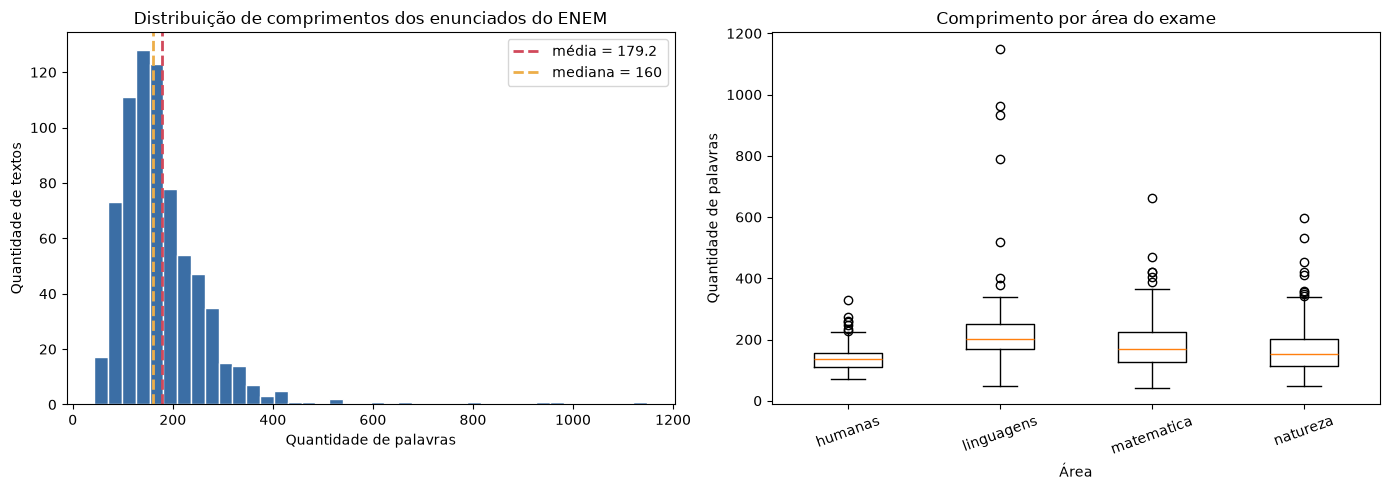

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma dos comprimentos
axes[0].hist(comprimentos, bins=40, color="#3b6ea5", edgecolor="white")
axes[0].axvline(comprimentos.mean(), color="#d1495b", linestyle="--", linewidth=2,
                label=f"média = {comprimentos.mean():.1f}")
axes[0].axvline(comprimentos.median(), color="#edae49", linestyle="--", linewidth=2,
                label=f"mediana = {comprimentos.median():.0f}")
axes[0].set_title("Distribuição de comprimentos dos enunciados do ENEM")
axes[0].set_xlabel("Quantidade de palavras")
axes[0].set_ylabel("Quantidade de textos")
axes[0].legend()

# Boxplot por área, para ver se o comprimento varia entre as áreas do exame
areas = sorted(df["area_classe"].unique())
axes[1].boxplot([df.loc[df["area_classe"] == a, "n_palavras"] for a in areas], tick_labels=areas)
axes[1].set_title("Comprimento por área do exame")
axes[1].set_xlabel("Área")
axes[1].set_ylabel("Quantidade de palavras")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

### Explicação

A distribuição é **assimétrica à direita**: cerca de 84% dos enunciados ficam abaixo de 250 palavras, mas há uma
cauda longa de textos bem maiores — até 1.148 palavras — formada por questões com textos de apoio, poemas e tabelas
transcritas. É por isso que a média (≈179) fica acima da mediana (160).

O boxplot por área mostra de onde vem essa cauda. Ordenando as áreas pela mediana:

| Área | Média | Mediana |
|---|---|---|
| Humanas | 140,0 | 136,0 |
| Natureza | 171,1 | 153,0 |
| Matemática | 182,9 | 168,0 |
| Linguagens | 222,6 | 201,5 |

**Linguagens** é a área de enunciados mais longos, o que faz sentido: é a área que apresenta textos literários,
tirinhas e reportagens completas antes da pergunta. **Humanas** é a mais curta — seus enunciados costumam trazer
citações breves seguidas de um comando direto. Vale notar que **Matemática não é a área mais curta**, ao contrário
do que a intuição sugeriria: as questões contextualizadas do ENEM descrevem situações-problema por extenso, e as
descrições de acessibilidade de gráficos e figuras ("abre parêntese", "eixo vertical") alongam bastante o texto.

---
## Questão 5

Aplique os seguintes passos de pré-processamento aos textos:

- Remova todas as palavras que contêm números;
- Converta as palavras para minúsculas;
- Remova pontuação;
- Tokenize os textos em palavras, gerando um dicionário único com *n* tokens e convertendo cada texto em um
  vetor de dimensão *n* com a respectiva contagem de palavras.

Em seguida, encontre as **10 palavras mais frequentes** da base de textos.

### Resposta — passos de pré-processamento

Os quatro passos são implementados como funções separadas e aplicados **na ordem do enunciado**. A ordem importa:
a remoção de palavras com números vem **antes** da remoção de pontuação, senão `"R$ 1.500,00"` viraria `"1 500 00"`
e o passo de remoção já não teria mais uma "palavra com números" para descartar — teria três tokens numéricos soltos.

In [14]:
import re

CONTEM_NUMERO = re.compile(r"\d")
# Tudo que não for letra (com acento), espaço ou hífen vira espaço.
PONTUACAO = re.compile(r"[^\w\s-]|_", re.UNICODE)
SEM_LETRAS = re.compile(r"^[^a-zà-ÿ]+$", re.IGNORECASE)


def remover_palavras_com_numeros(texto: str) -> str:
    """Passo 1: descarta qualquer palavra que contenha ao menos um dígito."""
    return " ".join(p for p in str(texto).split() if not CONTEM_NUMERO.search(p))


def para_minusculas(texto: str) -> str:
    """Passo 2: converte o texto para minúsculas."""
    return texto.lower()


def remover_pontuacao(texto: str) -> str:
    """Passo 3: substitui pontuação (inclusive aspas tipográficas e travessões) por espaço."""
    texto = texto.replace("’", "").replace("'", "")   # apóstrofos somem sem partir a palavra
    return PONTUACAO.sub(" ", texto)


def tokenizar(texto: str) -> list[str]:
    """Passo 4: quebra em tokens, descartando resíduos que não contêm nenhuma letra."""
    return [t for t in texto.split() if t and not SEM_LETRAS.match(t)]


def preprocessar(texto: str) -> list[str]:
    """Aplica os quatro passos do enunciado, na ordem, e devolve a lista de tokens."""
    texto = remover_palavras_com_numeros(texto)
    texto = para_minusculas(texto)
    texto = remover_pontuacao(texto)
    return tokenizar(texto)

In [15]:
# Demonstração passo a passo em um texto pequeno e artificial, para deixar cada etapa visível.
exemplo = 'Em 2023, o preço subiu R$ 1.500,00 — segundo o IBGE (dados de 2022)! “Não é pouco”, disse o Dr. Silva.'

print("ORIGINAL         :", exemplo)
e1 = remover_palavras_com_numeros(exemplo); print("1) sem números   :", e1)
e2 = para_minusculas(e1);                   print("2) minúsculas    :", e2)
e3 = remover_pontuacao(e2);                 print("3) sem pontuação :", e3)
e4 = tokenizar(e3);                         print("4) tokens        :", e4)

ORIGINAL         : Em 2023, o preço subiu R$ 1.500,00 — segundo o IBGE (dados de 2022)! “Não é pouco”, disse o Dr. Silva.
1) sem números   : Em o preço subiu R$ — segundo o IBGE (dados de “Não é pouco”, disse o Dr. Silva.
2) minúsculas    : em o preço subiu r$ — segundo o ibge (dados de “não é pouco”, disse o dr. silva.
3) sem pontuação : em o preço subiu r    segundo o ibge  dados de  não é pouco   disse o dr  silva 
4) tokens        : ['em', 'o', 'preço', 'subiu', 'r', 'segundo', 'o', 'ibge', 'dados', 'de', 'não', 'é', 'pouco', 'disse', 'o', 'dr', 'silva']


In [16]:
# Aplicação a toda a base.
textos_tokenizados = [preprocessar(t) for t in textos]

print(f"Textos processados           : {len(textos_tokenizados)}")
print(f"Total de tokens (ocorrências): {sum(len(t) for t in textos_tokenizados):,}".replace(",", "."))
print()
print("Primeiro texto da base — 40 primeiros tokens:")
print(textos_tokenizados[0][:40])

Textos processados           : 720
Total de tokens (ocorrências): 122.030

Primeiro texto da base — 40 primeiros tokens:
['descrição', 'do', 'pôster', 'pôster', 'intitulado', 'were', 'a', 'culture', 'not', 'a', 'costume', 'apresenta', 'fotos', 'de', 'quatro', 'pessoas', 'em', 'quatro', 'quadros', 'dois', 'acima', 'e', 'dois', 'abaixo', 'paralelamente', 'cada', 'pessoa', 'em', 'vestimentas', 'comuns', 'segura', 'imagens', 'de', 'pessoas', 'com', 'vestimentas', 'típicas', 'de', 'suas', 'culturas']


### Dicionário único com *n* tokens e vetorização por contagem

In [17]:
import numpy as np
from collections import Counter
from scipy.sparse import csr_matrix

# --- dicionário único (vocabulário) ---
frequencia_global = Counter()
for tokens in textos_tokenizados:
    frequencia_global.update(tokens)

vocabulario = sorted(frequencia_global)                       # ordem alfabética, determinística
indice_do_token = {token: i for i, token in enumerate(vocabulario)}
n = len(vocabulario)

print(f"n (tamanho do dicionário) = {n:,}".replace(",", "."))

# --- cada texto vira um vetor de dimensão n com as contagens ---
linhas, colunas, valores = [], [], []
for i, tokens in enumerate(textos_tokenizados):
    for token, contagem in Counter(tokens).items():
        linhas.append(i)
        colunas.append(indice_do_token[token])
        valores.append(contagem)

X = csr_matrix((valores, (linhas, colunas)), shape=(len(textos_tokenizados), n), dtype=np.int32)

densidade = X.nnz / (X.shape[0] * X.shape[1])
print(f"Matriz documento-termo    : {X.shape[0]} textos x {X.shape[1]} tokens")
print(f"Posições não nulas        : {X.nnz:,}".replace(",", "."))
print(f"Densidade                 : {densidade:.4%}  (por isso a matriz é guardada esparsa)")
print(f"Memória esparsa           : {(X.data.nbytes + X.indices.nbytes + X.indptr.nbytes) / 1e6:.1f} MB")
print(f"Memória se fosse densa    : {X.shape[0] * X.shape[1] * 4 / 1e6:.1f} MB")

n (tamanho do dicionário) = 16.888
Matriz documento-termo    : 720 textos x 16888 tokens
Posições não nulas        : 72.042
Densidade                 : 0.5925%  (por isso a matriz é guardada esparsa)
Memória esparsa           : 0.6 MB
Memória se fosse densa    : 48.6 MB


In [18]:
# O vetor de dimensão n de um texto específico, como pede o enunciado.
i = 0
vetor = X[i].toarray().ravel()

print(f"Texto {i} ({df['ID'].iloc[i]}) -> vetor de dimensão n = {vetor.shape[0]}")
print(f"Tokens distintos nesse texto   : {int((vetor > 0).sum())}")
print(f"Soma do vetor (total de tokens): {int(vetor.sum())}")
print()
print("Componentes não nulas mais altas desse vetor:")
for j in np.argsort(-vetor)[:12]:
    print(f"  posição {j:>6}  token '{vocabulario[j]}'".ljust(48) + f"contagem = {vetor[j]}")

Texto 0 (regular-2020-dia1_1) -> vetor de dimensão n = 16888
Tokens distintos nesse texto   : 135
Soma do vetor (total de tokens): 237

Componentes não nulas mais altas desse vetor:
  posição   4282  token 'de'                    contagem = 18
  posição      2  token 'a'                     contagem = 16
  posição   3094  token 'com'                   contagem = 8
  posição   5423  token 'e'                     contagem = 8
  posição  16022  token 'uma'                   contagem = 6
  posição  13037  token 'que'                   contagem = 5
  posição  14385  token 'segura'                contagem = 5
  posição  16021  token 'um'                    contagem = 5
  posição   7282  token 'foto'                  contagem = 4
  posição  13036  token 'quatro'                contagem = 4
  posição  16811  token 'é'                     contagem = 4
  posição  11961  token 'pessoa'                contagem = 4


### As 10 palavras mais frequentes da base

In [19]:
import pandas as pd

total_ocorrencias = sum(frequencia_global.values())
documentos_por_coluna = np.asarray((X > 0).sum(axis=0)).ravel()

top10_q5 = frequencia_global.most_common(10)

tabela_top10_q5 = pd.DataFrame(
    [
        {
            "posição": posicao,
            "palavra": palavra,
            "ocorrências": contagem,
            "% do corpus": round(100 * contagem / total_ocorrencias, 2),
            "textos em que aparece": int(documentos_por_coluna[indice_do_token[palavra]]),
        }
        for posicao, (palavra, contagem) in enumerate(top10_q5, start=1)
    ]
)

print("10 palavras mais frequentes APÓS o pré-processamento da questão 5:\n")
print(tabela_top10_q5.to_string(index=False))

10 palavras mais frequentes APÓS o pré-processamento da questão 5:

 posição palavra  ocorrências  % do corpus  textos em que aparece
       1      de         6569         5.38                    717
       2       a         5214         4.27                    717
       3       e         3781         3.10                    698
       4       o         3246         2.66                    681
       5     que         2099         1.72                    610
       6      do         2097         1.72                    608
       7      da         2070         1.70                    615
       8      em         1751         1.43                    592
       9      um         1521         1.25                    549
      10       é         1265         1.04                    469


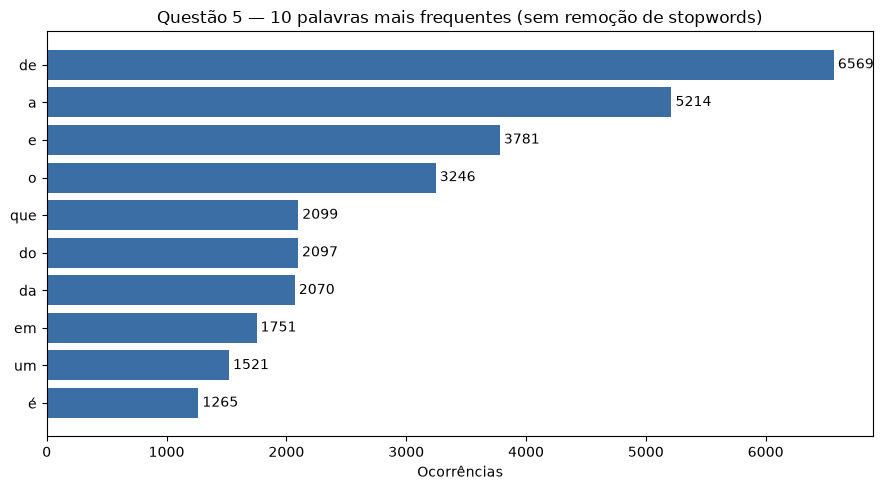

In [20]:
import matplotlib.pyplot as plt

palavras = [p for p, _ in top10_q5][::-1]
contagens = [c for _, c in top10_q5][::-1]

plt.figure(figsize=(9, 5))
plt.barh(palavras, contagens, color="#3b6ea5")
plt.title("Questão 5 — 10 palavras mais frequentes (sem remoção de stopwords)")
plt.xlabel("Ocorrências")
for i, c in enumerate(contagens):
    plt.text(c, i, f" {c}", va="center")
plt.tight_layout()
plt.show()

### Explicação

O resultado é o esperado e é justamente o que motiva a questão 6: **as 10 palavras mais frequentes são todas
*stopwords*** — artigos, preposições e conjunções (`de`, `a`, `o`, `que`, `e`, ...). Elas são as palavras mais
comuns de qualquer texto em português e, sozinhas, já respondem por uma fatia enorme das ocorrências do corpus,
sem dizer nada sobre o assunto das questões do ENEM.

Sobre a matriz documento-termo: com centenas de textos e um vocabulário de dezenas de milhares de tokens, a matriz densa
teria dezenas de milhões de posições, quase todas zero. Por isso ela é construída em formato **esparso**
(`csr_matrix`), guardando apenas as posições não nulas — `X[i].toarray()` recupera o vetor denso de dimensão *n*
de qualquer texto quando ele for necessário.

---
## Questão 6

Aplique os seguintes passos de pré-processamento aos textos processados na questão anterior:

- Remova *stopwords*;
- Realize rotulação de POS;
- Realize stemização;

**a)** Exiba os resultados em alguns textos.
**b)** Verifique quais são as 10 palavras mais frequentes e compare com as 10 palavras mais frequentes da questão anterior.
**c)** Repita a letra b) usando os tokens stemizados.
**d)** Verifique quais são as classes gramaticais mais frequentes.

### Preparação das ferramentas

- **Stopwords:** lista de português do NLTK, acrescida de alguns tokens recorrentes em enunciados de prova.
- **POS tagging:** o NLTK não traz um *tagger* pronto para português, então treinamos um
  `BigramTagger -> UnigramTagger -> DefaultTagger("N")` sobre o corpus **Mac-Morpho** (jornalismo em português do Brasil).
  O encadeamento por *backoff* garante que todo token receba alguma etiqueta.
- **Stemização:** `RSLPStemmer`, o algoritmo *Removedor de Sufixos da Língua Portuguesa*, que é o stemmer do NLTK
  específico para português (o Porter, mais conhecido, é para inglês).

In [21]:
import nltk

# Recursos necessários (já baixados ficam em cache; a chamada é idempotente).
for recurso in ["stopwords", "punkt", "punkt_tab", "rslp", "mac_morpho"]:
    nltk.download(recurso, quiet=True)

from nltk.corpus import stopwords, mac_morpho
from nltk.stem import RSLPStemmer
from nltk import DefaultTagger, UnigramTagger, BigramTagger

stopwords_pt = set(stopwords.words("portuguese"))
# Tokens muito frequentes no gênero "prova" e sem valor semântico para a análise.
stopwords_extra = {"sobre", "após", "onde", "ainda", "assim", "ser", "pode", "podem", "cada", "outro", "outra"}
STOPWORDS = stopwords_pt | stopwords_extra

print(f"Stopwords do NLTK (pt) : {len(stopwords_pt)}")
print(f"Stopwords utilizadas   : {len(STOPWORDS)}")
print(f"Amostra                : {sorted(stopwords_pt)[:20]}")

Stopwords do NLTK (pt) : 207
Stopwords utilizadas   : 217
Amostra                : ['a', 'ao', 'aos', 'aquela', 'aquelas', 'aquele', 'aqueles', 'aquilo', 'as', 'até', 'com', 'como', 'da', 'das', 'de', 'dela', 'delas', 'dele', 'deles', 'depois']


In [22]:
import time

# Treino do POS tagger em português sobre o Mac-Morpho.
inicio = time.time()
sentencas_treino = mac_morpho.tagged_sents()

tagger_padrao   = DefaultTagger("N")                                    # substantivo: etiqueta mais comum
tagger_unigrama = UnigramTagger(sentencas_treino, backoff=tagger_padrao)
POS_TAGGER      = BigramTagger(sentencas_treino, backoff=tagger_unigrama)

print(f"Sentenças de treino : {len(sentencas_treino):,}".replace(",", "."))
print(f"Tempo de treino     : {time.time() - inicio:.1f} s")
print()
print("Teste rápido:", POS_TAGGER.tag("o candidato analisou o gráfico apresentado na questão".split()))

Sentenças de treino : 51.397
Tempo de treino     : 31.6 s

Teste rápido: [('o', 'ART'), ('candidato', 'N'), ('analisou', 'V'), ('o', 'ART'), ('gráfico', 'N'), ('apresentado', 'PCP'), ('na', 'ADV'), ('questão', 'N')]


In [23]:
stemmer = RSLPStemmer()

def remover_stopwords(tokens: list[str]) -> list[str]:
    """Remove stopwords e tokens de 1 caractere (resíduos de pontuação e letras de alternativa)."""
    return [t for t in tokens if t not in STOPWORDS and len(t) > 1]

def rotular_pos(tokens: list[str]) -> list[tuple[str, str]]:
    """Rotulação morfossintática (POS) com o tagger treinado no Mac-Morpho."""
    return POS_TAGGER.tag(tokens)

def stemizar(tokens: list[str]) -> list[str]:
    """Stemização com o RSLP (Removedor de Sufixos da Língua Portuguesa)."""
    return [stemmer.stem(t) for t in tokens]

In [24]:
# Aplicação dos três passos a toda a base (partindo dos tokens da questão 5).
inicio = time.time()

tokens_sem_stopwords = [remover_stopwords(tokens) for tokens in textos_tokenizados]
tokens_pos           = [rotular_pos(tokens) for tokens in tokens_sem_stopwords]
tokens_stemizados    = [stemizar(tokens) for tokens in tokens_sem_stopwords]

print(f"Tempo de processamento : {time.time() - inicio:.1f} s")
print()
tokens_antes  = sum(len(t) for t in textos_tokenizados)
tokens_depois = sum(len(t) for t in tokens_sem_stopwords)
print(f"Tokens antes da remoção de stopwords : {tokens_antes:,}".replace(",", "."))
print(f"Tokens depois                        : {tokens_depois:,}".replace(",", "."))
print(f"Redução                              : {100 * (1 - tokens_depois / tokens_antes):.1f}%")
print()
print(f"Vocabulário (questão 5)              : {len(set().union(*textos_tokenizados)):,}".replace(",", "."))
print(f"Vocabulário sem stopwords            : {len(set().union(*tokens_sem_stopwords)):,}".replace(",", "."))
print(f"Vocabulário stemizado                : {len(set().union(*tokens_stemizados)):,}".replace(",", "."))

Tempo de processamento : 1.6 s

Tokens antes da remoção de stopwords : 122.030
Tokens depois                        : 68.947
Redução                              : 43.5%

Vocabulário (questão 5)              : 16.888
Vocabulário sem stopwords            : 16.687
Vocabulário stemizado                : 9.014


### a) Resultados em alguns textos

In [25]:
def exibir_texto(i: int, n_tokens: int = 18) -> None:
    print("=" * 100)
    print(f"TEXTO {i}  |  ID: {df['ID'].iloc[i]}  |  área: {df['area_classe'].iloc[i]}")
    print("=" * 100)
    print("\nORIGINAL (250 primeiros caracteres):")
    print(" ", textos[i][:250].strip(), "...")

    print(f"\n1) TOKENS DA QUESTÃO 5 ({len(textos_tokenizados[i])} tokens) — primeiros {n_tokens}:")
    print(" ", textos_tokenizados[i][:n_tokens])

    print(f"\n2) SEM STOPWORDS ({len(tokens_sem_stopwords[i])} tokens) — primeiros {n_tokens}:")
    print(" ", tokens_sem_stopwords[i][:n_tokens])

    print(f"\n3) ROTULAÇÃO POS — primeiros {n_tokens}:")
    print(" ", "  ".join(f"{t}/{tag}" for t, tag in tokens_pos[i][:n_tokens]))

    print(f"\n4) STEMIZAÇÃO — primeiros {n_tokens}:")
    print(" ", tokens_stemizados[i][:n_tokens])

    print("\n5) TOKEN -> POS -> STEM, lado a lado:")
    print(f"   {'TOKEN':<18} {'POS':<12} STEM")
    print("   " + "-" * 50)
    for (token, tag), stem in list(zip(tokens_pos[i], tokens_stemizados[i]))[:n_tokens]:
        print(f"   {token:<18} {tag:<12} {stem}")
    print()

# Um texto de cada área do exame.
for area in ["linguagens", "humanas", "natureza", "matematica"]:
    exibir_texto(int(df.index[df["area_classe"] == area][0]))

TEXTO 0  |  ID: regular-2020-dia1_1  |  área: linguagens

ORIGINAL (250 primeiros caracteres):
  Descrição do pôster: Pôster intitulado “We’re a culture, not a costume” apresenta fotos de quatro pessoas, em quatro quadros, dois acima e dois abaixo, paralelamente. Cada pessoa, em vestimentas comuns, segura imagens de pessoas com vestimentas típic ...

1) TOKENS DA QUESTÃO 5 (237 tokens) — primeiros 18:
  ['descrição', 'do', 'pôster', 'pôster', 'intitulado', 'were', 'a', 'culture', 'not', 'a', 'costume', 'apresenta', 'fotos', 'de', 'quatro', 'pessoas', 'em', 'quatro']

2) SEM STOPWORDS (150 tokens) — primeiros 18:
  ['descrição', 'pôster', 'pôster', 'intitulado', 'were', 'culture', 'not', 'costume', 'apresenta', 'fotos', 'quatro', 'pessoas', 'quatro', 'quadros', 'dois', 'acima', 'dois', 'abaixo']

3) ROTULAÇÃO POS — primeiros 18:
  descrição/N  pôster/N  pôster/N  intitulado/PCP  were/N  culture/N  not/N  costume/N  apresenta/V  fotos/N  quatro/NUM  pessoas/N  quatro/NUM  quadros/N  dois

### b) 10 palavras mais frequentes após a remoção de stopwords, comparadas com a questão 5

In [26]:
frequencia_sem_stopwords = Counter()
for tokens in tokens_sem_stopwords:
    frequencia_sem_stopwords.update(tokens)

top10_q6 = frequencia_sem_stopwords.most_common(10)
total_q6 = sum(frequencia_sem_stopwords.values())

tabela_top10_q6 = pd.DataFrame(
    [
        {"posição": i, "palavra": p, "ocorrências": c, "% do corpus": round(100 * c / total_q6, 2)}
        for i, (p, c) in enumerate(top10_q6, start=1)
    ]
)
print("10 palavras mais frequentes SEM stopwords (questão 6b):\n")
print(tabela_top10_q6.to_string(index=False))

10 palavras mais frequentes SEM stopwords (questão 6b):

 posição   palavra  ocorrências  % do corpus
       1     texto          341         0.49
       2 descrição          328         0.48
       3     igual          281         0.41
       4    figura          212         0.31
       5     vezes          204         0.30
       6 parêntese          185         0.27
       7        aa          180         0.26
       8        bb          180         0.26
       9        cc          180         0.26
      10        dd          180         0.26


In [27]:
comparacao = pd.DataFrame({
    "posição": range(1, 11),
    "Q5 - palavra": [p for p, _ in top10_q5],
    "Q5 - ocorr.": [c for _, c in top10_q5],
    "Q5 - é stopword?": ["sim" if p in STOPWORDS else "não" for p, _ in top10_q5],
    "Q6 - palavra": [p for p, _ in top10_q6],
    "Q6 - ocorr.": [c for _, c in top10_q6],
})
print("COMPARAÇÃO — questão 5 (com stopwords) x questão 6 (sem stopwords):\n")
print(comparacao.to_string(index=False))
print()
comuns = {p for p, _ in top10_q5} & {p for p, _ in top10_q6}
print(f"Palavras presentes nos dois rankings: {comuns if comuns else 'nenhuma'}")

COMPARAÇÃO — questão 5 (com stopwords) x questão 6 (sem stopwords):

 posição Q5 - palavra  Q5 - ocorr. Q5 - é stopword? Q6 - palavra  Q6 - ocorr.
       1           de         6569              sim        texto          341
       2            a         5214              sim    descrição          328
       3            e         3781              sim        igual          281
       4            o         3246              sim       figura          212
       5          que         2099              sim        vezes          204
       6           do         2097              sim    parêntese          185
       7           da         2070              sim           aa          180
       8           em         1751              sim           bb          180
       9           um         1521              sim           cc          180
      10            é         1265              sim           dd          180

Palavras presentes nos dois rankings: nenhuma


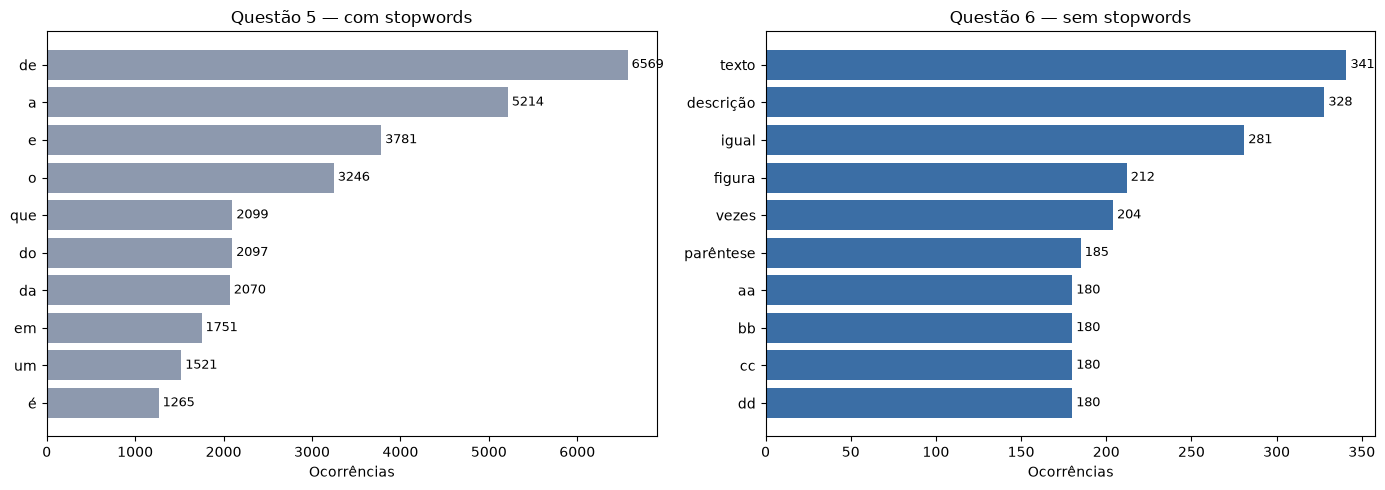

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, dados, titulo, cor in [
    (axes[0], top10_q5, "Questão 5 — com stopwords", "#8d99ae"),
    (axes[1], top10_q6, "Questão 6 — sem stopwords", "#3b6ea5"),
]:
    palavras = [p for p, _ in dados][::-1]
    contagens = [c for _, c in dados][::-1]
    ax.barh(palavras, contagens, color=cor)
    ax.set_title(titulo)
    ax.set_xlabel("Ocorrências")
    for i, c in enumerate(contagens):
        ax.text(c, i, f" {c}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

### c) 10 tokens mais frequentes usando os *stems*

In [29]:
frequencia_stems = Counter()
for tokens in tokens_stemizados:
    frequencia_stems.update(tokens)

top10_stems = frequencia_stems.most_common(10)

# Para cada stem, quais palavras originais foram agrupadas nele.
palavras_por_stem = {}
for tokens_orig, tokens_stem in zip(tokens_sem_stopwords, tokens_stemizados):
    for palavra, stem in zip(tokens_orig, tokens_stem):
        palavras_por_stem.setdefault(stem, Counter())[palavra] += 1

tabela_stems = pd.DataFrame(
    [
        {
            "posição": i,
            "stem": s,
            "ocorrências": c,
            "formas agrupadas": len(palavras_por_stem[s]),
            "exemplos de formas": ", ".join(w for w, _ in palavras_por_stem[s].most_common(4)),
        }
        for i, (s, c) in enumerate(top10_stems, start=1)
    ]
)
print("10 stems mais frequentes (questão 6c):\n")
print(tabela_stems.to_string(index=False))

10 stems mais frequentes (questão 6c):

 posição      stem  ocorrências  formas agrupadas                                    exemplos de formas
       1      text          384                 4                      texto, textos, textual, textuais
       2  apresent          343                16        apresenta, apresentam, apresentar, apresentada
       3     descr          330                 2                                 descrição, descrições
       4     igual          316                 4                    igual, iguais, igualmente, igualar
       5      form          296                18                      forma, formação, formas, formado
       6      dess          283                 4                          desse, dessa, desses, dessas
       7       vez          266                 2                                            vezes, vez
       8      pont          260                 6                            ponto, pontos, ponte, pont
       9      part      

In [30]:
comparacao_stems = pd.DataFrame({
    "posição": range(1, 11),
    "6b - palavra": [p for p, _ in top10_q6],
    "6b - ocorr.": [c for _, c in top10_q6],
    "6c - stem": [s for s, _ in top10_stems],
    "6c - ocorr.": [c for _, c in top10_stems],
    "ganho do stem": [c - frequencia_sem_stopwords.get(s, 0) for s, c in top10_stems],
})
print("COMPARAÇÃO — 6b (palavras) x 6c (stems):\n")
print(comparacao_stems.to_string(index=False))
print()
print(f"Vocabulário sem stemização : {len(frequencia_sem_stopwords):,}".replace(",", "."))
print(f"Vocabulário com stemização : {len(frequencia_stems):,}".replace(",", "."))
print(f"Redução do vocabulário     : {100 * (1 - len(frequencia_stems) / len(frequencia_sem_stopwords)):.1f}%")

COMPARAÇÃO — 6b (palavras) x 6c (stems):

 posição 6b - palavra  6b - ocorr. 6c - stem  6c - ocorr.  ganho do stem
       1        texto          341      text          384            384
       2    descrição          328  apresent          343            343
       3        igual          281     descr          330            330
       4       figura          212     igual          316             35
       5        vezes          204      form          296            294
       6    parêntese          185      dess          283            283
       7           aa          180       vez          266            204
       8           bb          180      pont          260            259
       9           cc          180      part          249            247
      10           dd          180 represent          246            246

Vocabulário sem stemização : 16.687
Vocabulário com stemização : 9.014
Redução do vocabulário     : 46.0%


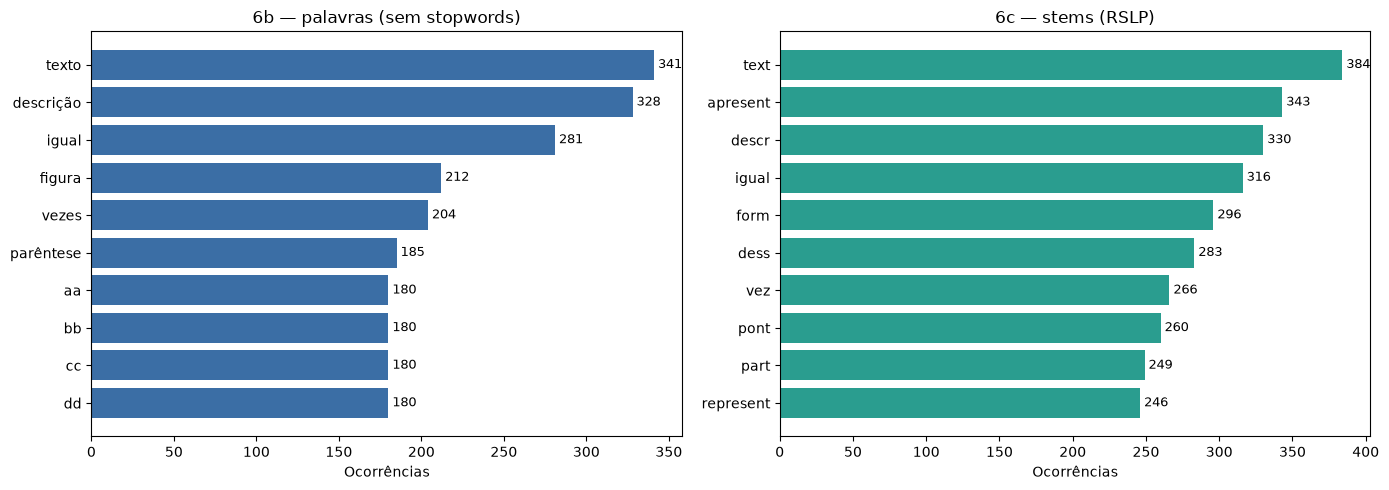

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, dados, titulo, cor in [
    (axes[0], top10_q6, "6b — palavras (sem stopwords)", "#3b6ea5"),
    (axes[1], top10_stems, "6c — stems (RSLP)", "#2a9d8f"),
]:
    rotulos = [p for p, _ in dados][::-1]
    contagens = [c for _, c in dados][::-1]
    ax.barh(rotulos, contagens, color=cor)
    ax.set_title(titulo)
    ax.set_xlabel("Ocorrências")
    for i, c in enumerate(contagens):
        ax.text(c, i, f" {c}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

### d) Classes gramaticais mais frequentes

In [32]:
DESCRICAO_TAG = {
    "N": "substantivo", "ADJ": "adjetivo", "V": "verbo", "VAUX": "verbo auxiliar",
    "PCP": "particípio", "PREP": "preposição", "ART": "artigo", "ADV": "advérbio",
    "PROADJ": "pronome adjetivo", "PROSUB": "pronome substantivo", "PROPESS": "pronome pessoal",
    "PRO-KS": "pronome conectivo subordinativo", "PRO-KS-REL": "pronome relativo conectivo",
    "KS": "conjunção subordinativa", "KC": "conjunção coordenativa",
    "NPROP": "nome próprio", "NUM": "numeral", "PDEN": "palavra denotativa",
    "IN": "interjeição", "CUR": "moeda", "PU": "pontuação", "ADV-KS": "advérbio conectivo",
    "ADV-KS-REL": "advérbio relativo conectivo",
}

def descrever(tag: str) -> str:
    """Descreve a tag do Mac-Morpho, ignorando sufixos do tipo 'PREP|+' e 'N|EST'."""
    return DESCRICAO_TAG.get(tag, DESCRICAO_TAG.get(tag.split("|")[0], "—"))

frequencia_tags = Counter(tag for texto in tokens_pos for _, tag in texto)
total_tags = sum(frequencia_tags.values())

tabela_tags = pd.DataFrame(
    [
        {"posição": i, "tag": tag, "classe gramatical": descrever(tag),
         "ocorrências": c, "%": round(100 * c / total_tags, 2)}
        for i, (tag, c) in enumerate(frequencia_tags.most_common(15), start=1)
    ]
)
total_formatado = f"{total_tags:,}".replace(",", ".")
print(f"Classes gramaticais mais frequentes ({total_formatado} tokens rotulados, {len(frequencia_tags)} tags distintas):\n")
print(tabela_tags.to_string(index=False))

Classes gramaticais mais frequentes (68.947 tokens rotulados, 29 tags distintas):

 posição    tag       classe gramatical  ocorrências     %
       1      N             substantivo        42559 61.73
       2    ADJ                adjetivo         9664 14.02
       3      V                   verbo         7466 10.83
       4    PCP              particípio         3266  4.74
       5    ADV                advérbio         1479  2.15
       6 PROADJ        pronome adjetivo          767  1.11
       7    NUM                 numeral          725  1.05
       8   VAUX          verbo auxiliar          513  0.74
       9   PREP              preposição          503  0.73
      10 PREP|+              preposição          417  0.60
      11  NPROP            nome próprio          415  0.60
      12  N|EST             substantivo          165  0.24
      13     KC  conjunção coordenativa          158  0.23
      14 PROSUB     pronome substantivo          157  0.23
      15     KS conjunção subord

In [33]:
# Palavras mais frequentes dentro de cada uma das principais classes gramaticais.
por_classe = {}
for texto in tokens_pos:
    for token, tag in texto:
        por_classe.setdefault(tag, Counter())[token] += 1

print("Palavras mais frequentes por classe gramatical:\n")
for tag, _ in frequencia_tags.most_common(6):
    exemplos = ", ".join(f"{w} ({c})" for w, c in por_classe[tag].most_common(8))
    print(f"{tag:<12} ({descrever(tag)}):")
    print(f"   {exemplos}\n")

Palavras mais frequentes por classe gramatical:

N            (substantivo):
   texto (341), descrição (328), parêntese (185), vezes (180), aa (180), bb (180), cc (180), dd (180)

ADJ          (adjetivo):
   igual (281), gráfico (157), maior (114), menor (87), primeira (78), social (76), diferentes (65), quadrado (65)

V            (verbo):
   apresenta (173), figura (114), abre (110), fecha (108), desse (97), representa (71), têm (69), forma (68)

PCP          (particípio):
   elevado (71), feito (33), dados (33), ligado (32), representado (31), composto (31), utilizada (29), sido (28)

ADV          (advérbio):
   menos (118), ponto (92), primeiro (69), meio (65), sempre (55), bem (52), cima (39), tão (36)

PROADJ       (pronome adjetivo):
   todos (76), mesma (62), outros (54), outras (53), alguns (49), todas (46), todo (35), algumas (31)



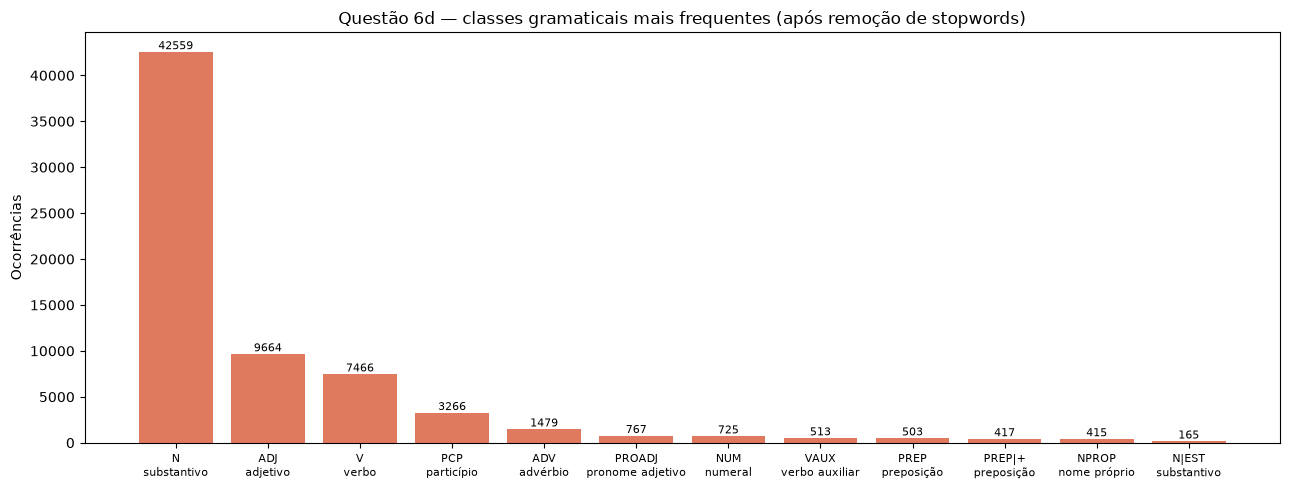

In [34]:
top_tags = frequencia_tags.most_common(12)
rotulos = [f"{t}\n{descrever(t)}" for t, _ in top_tags]
contagens = [c for _, c in top_tags]

plt.figure(figsize=(13, 5))
barras = plt.bar(rotulos, contagens, color="#e07a5f")
plt.title("Questão 6d — classes gramaticais mais frequentes (após remoção de stopwords)")
plt.ylabel("Ocorrências")
plt.xticks(fontsize=8)
for barra, c in zip(barras, contagens):
    plt.text(barra.get_x() + barra.get_width() / 2, c, f"{c}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

### Explicação e análise dos resultados

**b) O efeito da remoção de stopwords.** Os dois rankings não têm **nenhuma palavra em comum** — e, na questão 5,
as 10 primeiras posições eram ocupadas **inteiramente por stopwords** (`de`, `a`, `e`, `o`, `que`, ...), como a coluna
de verificação da tabela comparativa confirma. Removidas essas, emergem palavras de conteúdo ligadas ao gênero
textual "prova do ENEM": `texto`, `descrição`, `figura`, `parêntese` — vocabulário das descrições de acessibilidade
e dos comandos de enunciado.

A frequência absoluta do topo também despenca: a stopword mais comum aparecia **6.569** vezes, enquanto a palavra de
conteúdo mais comum aparece **341** vezes — quase 20 vezes menos. É exatamente o que se espera: stopwords têm alta
frequência e baixo poder discriminativo, e é por isso que são descartadas antes de tarefas de classificação ou
recuperação de informação.

**Ruído remanescente na base.** As posições 7 a 10 do ranking são ocupadas por `aa`, `bb`, `cc` e `dd`, com
exatamente **180 ocorrências cada** — uma regularidade que denuncia artefato, não linguagem. São os marcadores de
alternativa (`A`, `B`, `C`, `D`, `E`) saindo **duplicados** da extração do PDF, e as 180 ocorrências correspondem
exatamente às 180 questões da prova de **2023**, o único ano afetado que permanece na base. Registramos o achado sem
corrigi-lo aqui: a solução correta é ajustar o *scraper* do projeto, não remendar o texto a jusante.

**c) O efeito da stemização.** O RSLP corta sufixos de flexão e derivação, colapsando várias formas superficiais em
um mesmo radical (por exemplo, `texto`/`textos`, `apresenta`/`apresentado`/`apresentação`). Duas consequências
aparecem nos números: (i) a contagem de cada item do topo **sobe**, porque cada stem soma as ocorrências de todas as
formas que agrupa, e (ii) o **vocabulário encolhe** de forma expressiva. O preço disso é a legibilidade: o RSLP é
agressivo e produz radicais que não são palavras (`apresent`, `client`), e ocasionalmente junta palavras de sentidos
diferentes que compartilham radical. Quando a saída precisa ser legível ou o sentido precisa ser preservado, a
lematização é a escolha melhor — a stemização compensa quando o objetivo é apenas reduzir a dimensionalidade dos
vetores.

**d) As classes gramaticais.** O **substantivo (`N`)** domina com folga, seguido por **adjetivo (`ADJ`)** e
**verbo (`V`)**. Isso é consequência direta do passo anterior: ao remover stopwords, retiramos justamente artigos,
preposições, conjunções e pronomes — as classes fechadas —, deixando no corpus quase só as classes abertas, que
carregam o conteúdo. O resultado casa com o gênero textual: enunciados de prova são densos em termos técnicos
(substantivos) e qualificações (adjetivos).

**Dificuldades encontradas** Duas limitações que ocorreram na realização.

1. O tagger é treinado no **Mac-Morpho**, um corpus jornalístico, e aplicado a enunciados de prova — há um
   descasamento de domínio que custa acurácia em termos técnicos e vocabulário escolar.
2. A rotulação é aplicada **depois** da remoção de stopwords e sobre tokens já em minúsculas. Isso quebra o contexto
   sintático de que o `BigramTagger` depende e elimina a pista de maiúscula que distingue nomes próprios (`NPROP`),
   o que infla a etiqueta `N` via *backoff* do `DefaultTagger`. Fizemos assim porque o enunciado da questão 6 pede
   explicitamente que os três passos sejam aplicados "aos textos processados na questão anterior"; uma análise
   morfossintática de maior acurácia rotularia o texto **antes** de remover stopwords e preservando a caixa original.

---
## Resumo dos resultados

| Questão | Entregue |
|---|---|
| 1 | `isValidPassword` — 5 critérios via `re.search`/`re.fullmatch` + bateria de 9 testes |
| 2 | `isValidEmail` — regex montada regra a regra, com `fullmatch` + bateria de 16 testes |
| 3 | `extrairReferencia` — regex estrutural + `finditer` de autores, validada em 7 referências |
| 4 | Distribuição de comprimentos dos enunciados, tabela de faixas, histograma e boxplot por área |
| 5 | Pipeline de 4 passos, dicionário único de *n* tokens, matriz documento-termo esparsa e top-10 |
| 6 | Stopwords + POS (Mac-Morpho) + stemização (RSLP), com as comparações a), b), c) e d) |